In [ ]:

scenario = "2"
import yaml
import pandas as pd
config_file = f"./experiments/scenarios/{scenario}.yaml"
with open(config_file, "r") as f:
    config = yaml.safe_load(f)
    seeds = config["seeds"] #if args.seed == -1 else [args.seed]
    workload = config["workloads"][0]  # Assuming we want to run the first workload
    provider = config["provider"]
    maes = config["mae_forecast"] #if args.mae == -1 else [args.mae]
    periods = config["periods"]

import plotter.plotter as plotter
import plotter.style as style
path = f"./experiments/plots/{provider}"

import os 
if not os.path.exists(path):
    os.makedirs(path)

In [ ]:
!python postprocessing/summarize.py --scenario 2

In [ ]:

summary_df_ = pd.read_csv(
    f"experiments/out/{provider}/summary.csv",
    header=[0, 1],
    index_col=[0, 1, 2]
)

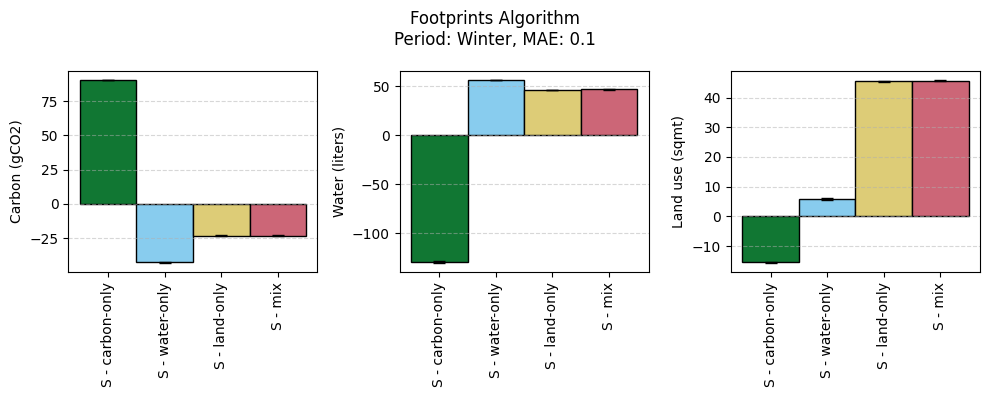

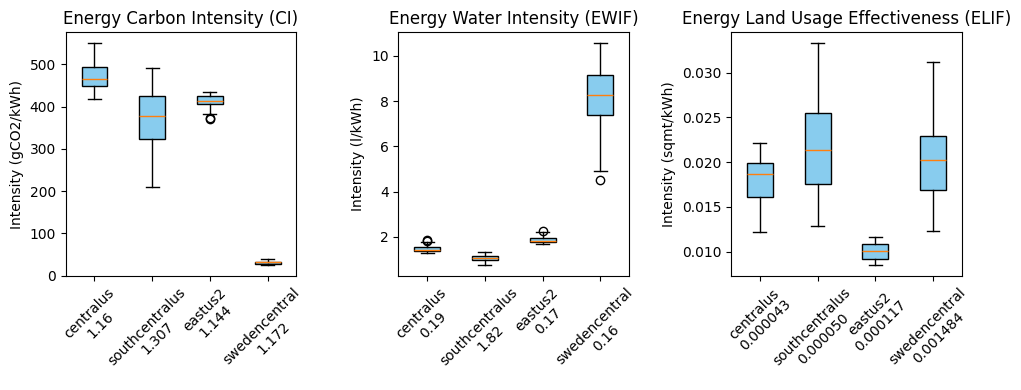

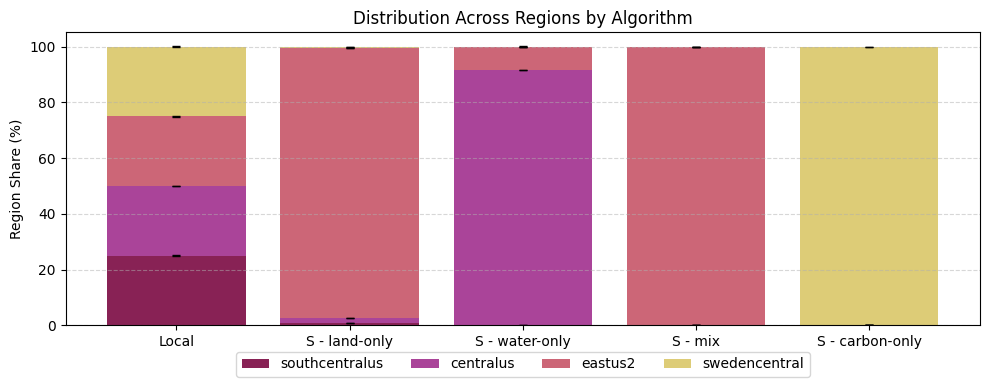

In [ ]:

plotter.plot_all_algo_all_factors(summary_df_, 0.1, "winter", "./experiments/plots/azure", improvement=True, provider="azure", 
    custom_order = [
        "L",
        "R_[1.0, 0.0, 0.0]",
        "R_[0.0, 1.0, 0.0]", 
        "R_[0.0, 0.0, 1.0]", 
        "R_[0.333, 0.333, 0.334]"
        ]
        )
plotter.plot_intensity_boxplots(providers = ["azure"], mae=0.1, period=periods["winter"], period_name="winter")
plotter.region_load_distribution_plot(summary_df_, "./experiments/plots/azure", "azure")

In [ ]:

# Define the subset of algorithms to compare
subset_algorithms = [
            "R_[1.0, 0.0, 0.0]",
            "R_[0.0, 1.0, 0.0]",
            "R_[0.0, 0.0, 1.0]", 
            "R_[0.333, 0.333, 0.334]", 
        ]

# Select relevant columns for the table
columns = [
    #("tot_carbon_footprint_actual", "mean"),
    #("tot_carbon_footprint_actual", "std"),
    ("tot_carbon_footprint_actual_improvement", "mean"),
    ("tot_carbon_footprint_actual_improvement", "std"),
    #("tot_water_footprint_actual", "mean"),
    #("tot_water_footprint_actual", "std"),
    ("tot_water_footprint_actual_improvement", "mean"),
    ("tot_water_footprint_actual_improvement", "std"),
    #("tot_land_use_footprint_actual", "mean"),
    #("tot_land_use_footprint_actual", "std"),
    ("tot_land_use_footprint_actual_improvement", "mean"),
    ("tot_land_use_footprint_actual_improvement", "std")

]

# Filter the summary_df_ for the subset of algorithms and all periods, for a fixed mae (e.g., 0.1)
mae_value = 0.1
latex_df = summary_df_.loc[(subset_algorithms, mae_value, slice(None)), columns]

# Reset index for better formatting
latex_df = latex_df.reset_index()

# Rename columns for LaTeX clarity
latex_df = latex_df.drop(columns=["mae"])
latex_df["algorithm"] =  latex_df["algorithm"].apply(lambda algo: style.style[algo]["name"])
latex_df = latex_df.rename(columns={
    "tot_carbon_footprint_actual_improvement": "carbon improvement",
    "tot_water_footprint_actual_improvement": "water improvement",
    "tot_land_use_footprint_actual_improvement": "land use improvement"
    })


print(latex_df.groupby(["algorithm","period"]).first().to_latex(index=True, float_format="%.2f"))


\begin{tabular}{llrrrrrr}
\toprule
 &  & \multicolumn{2}{r}{carbon improvement} & \multicolumn{2}{r}{water improvement} & \multicolumn{2}{r}{land use improvement} \\
 &  & mean & std & mean & std & mean & std \\
algorithm & period &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{S - carbon-only} & autumn & 91.28 & 0.03 & -118.26 & 0.75 & -8.10 & 0.46 \\
 & spring & 86.56 & 0.04 & -139.90 & 1.17 & 18.29 & 0.32 \\
 & summer & 91.87 & 0.02 & -123.28 & 1.15 & -13.85 & 0.29 \\
 & winter & 90.55 & 0.03 & -129.41 & 1.12 & -15.46 & 0.26 \\
\cline{1-8}
\multirow[t]{4}{*}{S - land-only} & autumn & -25.17 & 0.50 & 40.90 & 0.30 & 57.00 & 0.17 \\
 & spring & -15.63 & 0.35 & 34.32 & 0.37 & 42.24 & 0.22 \\
 & summer & -13.88 & 0.41 & 39.31 & 0.36 & 37.54 & 0.12 \\
 & winter & -23.12 & 0.42 & 46.16 & 0.27 & 45.40 & 0.19 \\
\cline{1-8}
\multirow[t]{4}{*}{S - mix} & autumn & -25.86 & 0.49 & 42.35 & 0.27 & 57.16 & 0.17 \\
 & spring & -23.35 & 0.35 & 49.22 & 0.24 & 42.73 & 0.22 \\
 & summer & -17.64 & 0.4

/var/folders/8j/mm9mhpn90656nxcsvrdck4sm0000gn/T/ipykernel_25156/3236006821.py:35: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  latex_df = latex_df.drop(columns=["mae"])
/var/folders/8j/mm9mhpn90656nxcsvrdck4sm0000gn/T/ipykernel_25156/3236006821.py:44: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  print(latex_df.groupby(["algorithm","period"]).first().to_latex(index=True, float_format="%.2f"))


In [6]:
period = "winter"
latex_df_mae = summary_df_.loc[(subset_algorithms, slice(None), period), columns]

# Reset index for better formatting
latex_df_mae = latex_df_mae.reset_index()

# Rename columns for LaTeX clarity
latex_df_mae = latex_df_mae.drop(columns=["period"])
latex_df_mae["algorithm"] =  latex_df_mae["algorithm"].apply(lambda algo: style.style[algo]["name"])
latex_df_mae = latex_df_mae.rename(columns={
    "tot_carbon_footprint_actual_improvement": "carbon improvement",
    "tot_water_footprint_actual_improvement": "water improvement",
    "tot_land_use_footprint_actual_improvement": "land use improvement"
    })

print(latex_df_mae.groupby(["algorithm","mae"]).first().to_latex(index=True, float_format="%.2f"))

\begin{tabular}{llrrrrrr}
\toprule
 &  & \multicolumn{2}{r}{carbon improvement} & \multicolumn{2}{r}{water improvement} & \multicolumn{2}{r}{land use improvement} \\
 &  & mean & std & mean & std & mean & std \\
algorithm & mae &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{S - carbon-only} & 0.050000 & 90.55 & 0.03 & -129.41 & 1.12 & -15.46 & 0.26 \\
 & 0.100000 & 90.55 & 0.03 & -129.41 & 1.12 & -15.46 & 0.26 \\
 & 0.150000 & 90.55 & 0.03 & -129.41 & 1.12 & -15.46 & 0.26 \\
 & 0.200000 & 90.55 & 0.03 & -129.41 & 1.12 & -15.46 & 0.26 \\
\cline{1-8}
\multirow[t]{4}{*}{S - land-only} & 0.050000 & -23.40 & 0.43 & 47.12 & 0.28 & 45.71 & 0.18 \\
 & 0.100000 & -23.12 & 0.42 & 46.16 & 0.27 & 45.40 & 0.19 \\
 & 0.150000 & -22.33 & 0.42 & 44.14 & 0.29 & 44.85 & 0.18 \\
 & 0.200000 & -22.03 & 0.42 & 42.84 & 0.30 & 44.15 & 0.19 \\
\cline{1-8}
\multirow[t]{4}{*}{S - mix} & 0.050000 & -23.34 & 0.43 & 47.10 & 0.28 & 45.74 & 0.18 \\
 & 0.100000 & -23.34 & 0.43 & 47.10 & 0.28 & 45.74 & 0.18 \\
 & 0.

/var/folders/8j/mm9mhpn90656nxcsvrdck4sm0000gn/T/ipykernel_25156/1619432841.py:8: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  latex_df_mae = latex_df_mae.drop(columns=["period"])
/var/folders/8j/mm9mhpn90656nxcsvrdck4sm0000gn/T/ipykernel_25156/1619432841.py:16: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  print(latex_df_mae.groupby(["algorithm","mae"]).first().to_latex(index=True, float_format="%.2f"))
